# context (문서) 분석


- 문서 길이 분포 (문자수/토큰수)
- context 내에 answer text가 항상 존재하는지 체크
- document_id 기준 문서 개수 확인
- title별 문서 분포(어떤 주제가 많은지)
- context의 난이도(문장 수, named entity 수 등)


In [1]:
import json
from datasets import load_from_disk

with open("../../data/wikipedia_documents.json", "r", encoding="utf-8") as file:
    data = json.load(file)
wiki_docs = list(dict.fromkeys([v["text"] for v in data.values()]))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer

In [3]:
klue_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# tokenize
tokenized_wiki_docs = []
for wiki_doc in wiki_docs:
    tokenized_wiki_docs.append(klue_tokenizer.tokenize(wiki_doc))

/data/ephemeral/git/pro-nlp-mrc-nlp-01/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1131 > 512). Running this sequence through the model will result in indexing errors


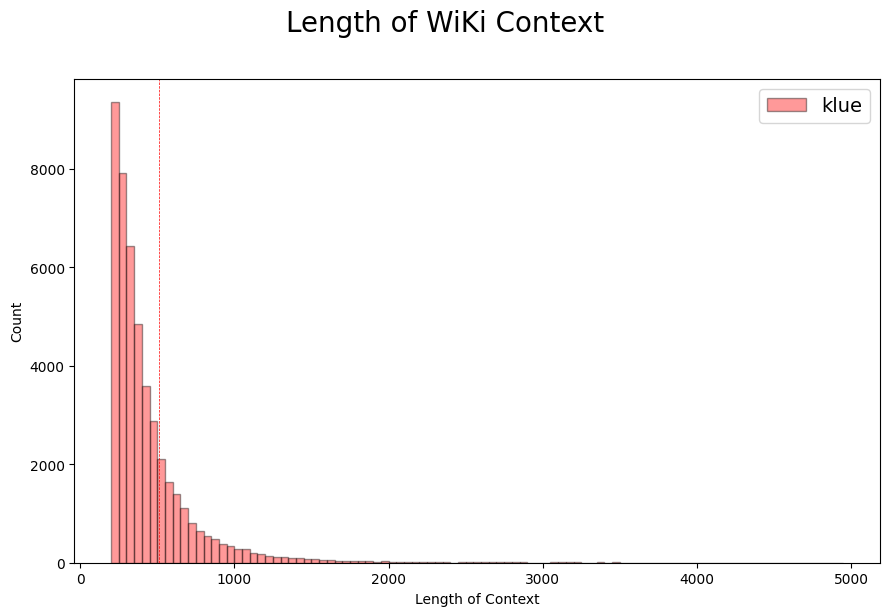

In [5]:
klue_tokenized_wiki_docs_len = [len(tokens) for tokens in tokenized_wiki_docs]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 6))
fig.suptitle("Length of WiKi Context", fontsize=20, y=1.02)

ax.hist(klue_tokenized_wiki_docs_len, bins=np.arange(200, 5000, 50), alpha=0.4, color='red', edgecolor='black', label='klue')
ax.set_xlabel('Length of Context')
ax.set_ylabel('Count')
ax.legend(fontsize=14)
plt.axvline(x=512, color='red', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [7]:
over_512 = sum(l > 512 for l in klue_tokenized_wiki_docs_len)
print(f"512 토큰 초과 문서 비율: {over_512 / len(klue_tokenized_wiki_docs_len) * 100:.2f}%")


512 토큰 초과 문서 비율: 19.72%


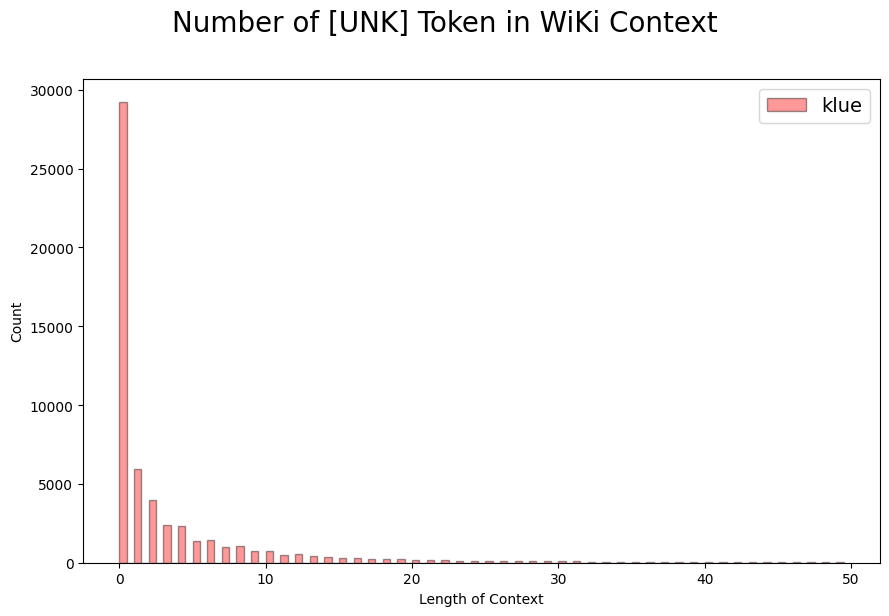

In [9]:
klue_wiki_unk_token = list(map(lambda x: x.count('[UNK]'),tokenized_wiki_docs))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9, 6))
fig.suptitle("Number of [UNK] Token in WiKi Context", fontsize=20, y=1.02)

ax.hist(klue_wiki_unk_token, bins=np.arange(0, 50, 0.5), alpha=0.4, color='red', edgecolor='black', label='klue')
ax.set_xlabel('Length of Context')
ax.set_ylabel('Count')
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

## 한국어 비율 계산

In [12]:
import re
import pandas as pd

# DataFrame 변환
df = pd.DataFrame({"text": wiki_docs})

# 줄바꿈(\n, \\n) 제거
df["text"] = df["text"].str.replace(r'\\n|\n', ' ', regex=True)

# 한국어 + 숫자 + 일반 특수기호 비율 계산 함수
def korean_ratio(text):
    korean_number_special_count = len(re.findall(r"[가-힣0-9,\.\/'\"#\(\)\!\^\*\@\+\`\_\-\~\$\%\&\=\:\;\?\>\< ]", text))
    total_count = len(text)
    return korean_number_special_count / total_count if total_count > 0 else 0

# 각 문서별 한국어 비율 계산
df["korean_ratio"] = df["text"].apply(korean_ratio)

# 평균 한국어 비율 출력
average_korean_ratio = df["korean_ratio"].mean()
print(f"Average Korean ratio: {average_korean_ratio:.4f}")


Average Korean ratio: 0.9355


In [14]:
import re
import pandas as pd

# wiki_docs는 이미 로드되어 있다고 가정
df = pd.DataFrame({"text": wiki_docs})

# 줄바꿈(\n, \\n) 제거
df["text"] = df["text"].str.replace(r'\\n|\n', ' ', regex=True)

# 한국어 + 숫자 비율 계산 (특수문자 제외)
def korean_ratio_no_symbols(text):
    korean_number_count = len(re.findall(r"[가-힣0-9]", text))
    total_count = len(text)
    return korean_number_count / total_count if total_count > 0 else 0

# 각 문서별 비율 계산
df["korean_ratio_no_symbols"] = df["text"].apply(korean_ratio_no_symbols)

# 평균 비율 계산 및 출력
average_korean_ratio_no_symbols = df["korean_ratio_no_symbols"].mean()
print(f"Average Korean ratio (excluding symbols, keeping numbers): {average_korean_ratio_no_symbols:.4f}")


Average Korean ratio (excluding symbols, keeping numbers): 0.6701


In [16]:
import re
import pandas as pd

# wiki_docs는 이미 로드되어 있다고 가정
df = pd.DataFrame({"text": wiki_docs})

# 줄바꿈 제거
df["text"] = df["text"].str.replace(r'\\n|\n', ' ', regex=True)

# 특수문자 비율 계산 함수 (한글·숫자 제외)
def special_char_ratio(text):
    special_count = len(re.findall(r"[^가-힣0-9\s]", text))  # 한글, 숫자, 공백 제외
    total_count = len(text)
    return special_count / total_count if total_count > 0 else 0

# 특수문자 비율 계산
df["special_ratio"] = df["text"].apply(special_char_ratio)

# 상위 5개 출력 (특수문자 비율 높은 문서)
top_special = df.sort_values("special_ratio", ascending=False).head(5)

pd.set_option('display.max_colwidth', None)
print("[특수문자 비율 상위 5개 문서]")
display(top_special[["special_ratio", "text"]])
pd.set_option('display.max_rows', 50)

[특수문자 비율 상위 5개 문서]


,special_ratio,text
52716,0.980319,大唐故右威衛將軍上柱國禰公墓志銘幷序 公諱軍，字温，熊津嵎夷人也。其先与華同祖，永嘉末，避亂適東，因遂家焉。若夫巍巍鯨山，跨淸丘以東峙；淼淼熊水，臨丹渚以南流。浸烟雲以檎英，降之於蕩沃；照日月而榳惁，秀之于蔽虧，靈文逸文，高前芳於七子；汗馬雄武，擅後異於三韓；華構增輝，英材繼響，綿圖不絕，奕代有聲。 曾祖福，祖譽，父善，皆是本藩一品，官号佐平。幷緝地義以光身，佩天爵而懃國。忠侔鐵石，操埒松筠。范物者，道德有成；則士者，文武不堅。公狼輝襲祉，䴏頷生姿。涯濬澄陂，裕光愛日，干牛斗之逸气，芒照星中；博羊角之英風，影征雲外。去顯慶五年，官軍平本藩日，見機識變，杖劍知歸。似由余之出戎，如金磾之入漢。聖上嘉歎，擢以榮班，授右武衛滻川府折衝都尉。于時日本餘噍，据扶桑以逋誅；風谷遺甿，負盤桃而阻固。萬騎亘野，与盖馬以驚塵；千艘橫波，援原虵而縱濔。以公格謨海左，龜鏡瀛東，特在簡帝，往尸招慰。公侚臣節而投命，歌皇華以載馳。飛泛海之蒼鷹，翥凌山之赤雀。决河眥而天吳靜，鑒風隧而雲路通。驚鳧失侶，濟不終夕，遂能說暢天威，喻以禍福千秋。 僭帝一旦稱臣，仍領大首望數十人將入朝謁，特蒙恩詔授左戎衛郎將。少選遷右領軍衛中郎將兼檢校熊津都督府司馬。材光千里之足，仁副百城之心。舉燭靈臺，器標於芃棫；懸月神府，芳掩於桂符。衣錦晝行，富貴無革。歡蒲夜寢，字育有方。去咸亨三年十一月廿一日詔授右威衛將軍。 局影彤闕，飾恭紫陛。亟蒙榮晋，驟歷便繁。方謂克壯淸猷，永綏多祐。豈啚曦馳易往，霜凋馬陵之樹；川閱難留，風驚龍驤之水。 以儀鳳三年歲在戊寅二月朔戊子十九日景午遘疾，薨於雍州長安縣之延壽里第。春秋六十有六。 皇情念功惟舊，傷悼者久之，贈絹布三百段，粟三百升，葬事所須，幷令官給，仍使弘文館學士兼檢校本衛長史王行本監護。惟公雅識淹通，溫儀韶峻，明珠不纇，白珪無玷。十步之芳蘭，室欽其臭味； 四鄰之彩桂，嶺尙其英華。奄墜扶搖之翼，遽輟連舂之景。粤以其年十月甲申朔二日乙酉葬於雍州乾封縣之高陽里，禮也。 駟馬悲鳴，九原長往，月輪夕駕，星精夜上。日落山兮草色寒，風度原兮松聲響。陟文榭兮可通，隨武山兮安仰。愴淸風之歇滅，樹芳名於壽像。其詞曰： 胄胤靑丘，芳基華麗。脈遠遐邈，會逢時濟。茂族淳秀，奕葉相繼。獻款夙彰，隆恩無替。其一。 惟公苗裔，桂馥蘭芬。緒榮七貴，乃子傳孫。流芳後代，播美來昆。英聲雖歇，令範猶存。其二。 牖箭驚秋，隟駒遄暮。名將日遠，德隨年故。慘松吟於夜風，悲薤哥於朝露。靈轜兮遽轉，嘶驂兮跼顧。嗟陵谷之貿遷，覬音徽之靡蠹。其三。
49313,0.924119,"<blockquote class=""toccolours"" style=""margin:1px 1px; padding: 10px 15px 10px 15px; display:table; {}""> {} 윤봉조(尹鳳朝, 1680~1761), <호해정기(湖海亭記)> <br/><br/> 滙而爲湖。拓而爲海。截其間。又爲一沙埭。置數三漁戶。錯落如畫圖。前有石峰涌海。遠望益奇峭者。歙之侍中㙜所據之勝也。㙜距邑治廑五里。前浸湖水。後被萬株松。其始由林木中入。及乎㙜而始豁然通眺。俗傳故宰相上黨韓公遊是㙜。適其日聞拜相。故遂以侍中爲號。嶺之東並海而亭㙜者幾十數。㙜其一也。近歙之地。若通之叢石亭。高之三日浦。䧺詭瑰奇。遊者之所歸趨。而彼其有海者或無湖。有湖者又無海。未有如是㙜攬湖海之全。歸之几席之內。其品論a193_360a之定。又未易遽言也。獨是㙜只據其天設。而人未有賁餙者。無亭榭可以延憇。無舸舫可以留連。遊者咸以是病之。趙侯鳳周始至。慨然有意。亟捐財庀工。搆亭於㙜之顚。斥其餘。又治一小艇。備其沿濯。而遊事始無憾。亭旣成。侯就以名之曰湖海。志其所矚。且欲托於陳元龍之豪氣以自見。夫論天下偉觀者。必之湖海。是能振發乎耳目。培植乎風槩。氣足以抗千古之豪。而物無攖於前矣。然吾聞君子不專恃血氣。而一遊一觀。皆有其則。恬平瑩淨。蘊爲德性。而喩其明於湖者心也。開廓涵迤。恢爲度量。而絜其廣於海者a193_360b器也。是之謂昭曠之見。而命之曰眞正大豪䧺。不亦可乎。孟子論浩然之氣。必先以黝舍爲開端。吾未知侯所稱元龍者。姑以發其端。而其微意所不言。欲使人自會歟。苟無以發揮之。則吾又恐大觀之旨荒矣。侯有書索余文。旣以是復之。因以記其亭。 </blockquote>"
20670,0.902632,":Bolivianos Viuusamrecre viti :Titecpopo yvoo""ogne vit :Tiuchcu""po pjoca vye""e ""pog""e :Titovopo to naemponnosiravi :Tiutsio""choo""ini ""chopegiene nae""rorisra :Taegnepo to ""chopegiene guerra :Tcutcucompo tiuriono tajicho :Taegnepo titotijvocrepo vjirosare :Pjoca ""pog""e :Toonagne taéjare :Vechpojricgienenajíchapo viti :Te tamíro""u vijroca vechjiriivo :Vepenapo vovcuquimponnojcosi."
39357,0.902256,『Kis-My-Ft2 NON-STOP MIX -Vol.1-』Everybody Go～SHE! HER! HER!～アイノビート -Dance ver.-～Shake It Up～Kiss魂～ETERNAL MIND～Hair～Another Future if～My Resistance -タシカナモノ-～光のシグナル～ダイスキデス～SNOW DOMEの約束～サクラヒラリ～Smile～S.O.S (Smile On Smile) Tell me why～Luv Sick～WANNA BEEEE!!!～運命Girl～キ・ス・ウ・マ・イ～KISS YOUR MIND～Brand New Season～Kis-My-LAND～My Love キミとのキセキ～We never give up！～3D Girl～FIRE BEAT～Kis-My-Calling!～Thank youじゃん！
31653,0.901865,"제관의 《천태사교의》에 기술된 바에 의거하여,제관 록|T.1931|loc=p. T46n1931_p0776a05 - T46n1931_p0776b21. 고제와 25유|ps""自下明化法四教。第一三藏教者。一修多羅藏(四阿含等經)二阿毘曇藏(俱舍婆沙等論)三毘尼藏(五部律)此之三藏名通大小。今取小乘三藏也。大智度論云。迦旃延子。自以聰明利根。於婆沙中明三藏義。不讀衍經。非大菩薩。又法華云。貪著小乘三藏學者。依此等文故。大師稱小乘為三藏教。此有三乘根性。初聲聞人依生滅四諦教。言四諦者。一苦諦。二十五有依正二報是。言二十五有者。四洲四惡趣六欲。并梵天四禪四空處無想五那含(四洲四趣成八。六欲天并梵王天成十五。四禪四空處成二十三。無想天及那含天成二十五)別則二十五有。總則六道生死。一地獄道。梵語捺洛迦。又語泥黎。此翻苦具。而言地獄者。此處在地之下。故言地獄。謂八寒八熱等大獄。各有眷屬其類無數。其中受苦者。隨其作業各有輕重。經劫數等。其最重處。一日之中八萬四千生死。經劫無量。作上品五逆十惡者。感此道身。二畜生道。亦云旁生。此道遍在諸處。披毛戴角。鱗甲羽毛。四足多足。有足無足。水陸空行。互相吞噉。受苦無窮。愚癡貪欲作中品五逆十惡者。感此道身。三餓鬼道。梵語闍黎哆。此道亦遍諸趣。有福德者。作山林塚廟神。無福德者。居不淨處。不得飲食。常受鞭打填河塞海。受苦無量。諂誑心意作下品五逆十惡。感此道身。四阿修羅道。此翻無酒。又無端正又無天。或在海岸海底宮殿嚴飾。常好鬥戰怕怖無極。在因之時懷猜忌心。雖行五常欲勝他故。作下品十善。感此道身。五人道。四洲不同。謂東弗婆提(壽二百五十歲)南閻浮提(壽一百歲)西瞿耶尼(壽五百歲)北鬱單越(壽一千歲命無中夭。聖人不出其中。即八難之一)皆苦樂相間。在因之時行五常五戒。五常者。仁義禮智信。五戒者。不殺不盜不邪淫不妄語不飲酒。行中品十善。感此道身。六天道。二十八天不同(欲界六天。色界十八天。無色界四天)初欲界六天者。一四天王天(居須彌山腹)二忉利天(居須彌山頂。自有三十三天。已上二天單修上品十善。得生其中)三夜摩天。四兜率天。五化樂天。六他化自在天(已上四天空居。修上品十善。兼坐未到定。得生其中)次色界十八天分為四禪。初禪三天(梵眾梵輔大梵)二禪三天(少光無量光光音)三禪三天(少淨無量淨遍淨)四禪九天(無雲福生廣果。已上三天凡夫住處。修上品十善坐禪者得生其中。無想天外道所居。無煩無熱善見善現色究竟。已上五天第三果居處。上之九天離欲麤散。未出色籠故名色界。坐得禪定故得禪名)三無色界四天(空處識處無所有處非非想。已上四天只有四陰而無色蘊。故得名也)上來所釋。從地獄至非非想天。雖然苦樂不同。未免生而復死死已還生。故名生死。此是藏教實有苦諦。"" 25유(二十五有)를 3계 6도로 분별하면 다음과 같다.loc=""二十五有"". 2013년 6월 6일에 확인loc=""二十五有"". 2013년 6월 6일에 확인"
